In [1]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)


import pandas as pd
from utils.results import *


## 1.1: Grid (Sample Size x P_noise) (Noisy Logic Gates) 

In [9]:
import pickle

subset = 'binary_data'
# subset = 'toyMedium'

def load_results(subset, base_dir= "results", ):
    global results_by_label

    with open(f'{base_dir}/pc/{subset}.pkl', 'rb') as f:
        results_pc = pickle.load(f)
    
    with open(f'{base_dir}/ges/{subset}.pkl', 'rb') as f:
        results_ges = pickle.load(f)
    
    with open(f'{base_dir}/hc/{subset}.pkl', 'rb') as f:
        results_hc = pickle.load(f)

    with open(f'{base_dir}/ea_fg/{subset}.pkl', 'rb') as f:
        results_ea_fg = pickle.load(f)

    with open(f'{base_dir}/ea_hc/{subset}.pkl', 'rb') as f:
        results_hc_inf = pickle.load(f)

    # with open(f'results/ea_ues/{subset}.pkl', 'rb') as f:
    #     results_ea_ues = pickle.load(f)

    with open(f'results/ea_ies/{subset}.pkl', 'rb') as f:
        results_ea_ies = pickle.load(f)
    
    # with open(f'results/ea_fes/{subset}.pkl', 'rb') as f:
    #     results_ea_fes = pickle.load(f)

    # with open(f'results/ea_upu/{subset}.pkl', 'rb') as f:
    #     results_ea_upu = pickle.load(f)
    # with open(f'results/ea_ipu/{subset}.pkl', 'rb') as f:
    #     results_ea_ipu = pickle.load(f)
    

    results_by_label = {
        "PC": results_pc,
        "GES": results_ges,
        "HC": results_hc,
        "EA Informed": results_ea_ies,
        "EA Final Greedy": results_ea_fg,
        "HC Informed": results_hc_inf,
        # "EA Uninformed": results_ea_ues,
        # "EA Fully Informed": results_ea_fes,
        # "EA Uninformed (PU)": results_ea_upu,
        # "EA Informed (PU)": results_ea_ipu,
    }
    
load_results(subset)
x_col="samples"
y_col="p_noise"
# filter = ("samples", 10_000)
# filter = ("n_xor", 10)
# filter = ("p_syn", 1)
filter = ("dag_family", "ba")
filter_col, filter_val = filter

### Metrics Comparison 

In [10]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# --- UI ---
metric_dropdown = widgets.Dropdown(
    options=["Recall (Collider)", "F1 (Collider)", "SHD [CPDAG]", "SHD [Skeleton]", "Recall (Synergy)", "Recall (Pairwise)"],
    value="Recall (Collider)",
    description="Metric:",
)

out = widgets.Output()

def render(metric: str):
    """Render the heatmap for the selected metric."""
    with out:
        clear_output(wait=True)

        # Important: close prior figures to avoid stacking / memory leaks
        plt.close("all")

        fig, axes = plot_final_heatmap(
            results_by_label,
            filter=filter,
            subset_metrics=[metric, x_col, y_col, filter_col],
            plot_metric=metric,
            aggfunc="max",
            x_col=x_col,
            y_col=y_col,
        )

        # Ensure the latest figure is shown in the output area
        plt.show()

def on_metric_change(change):
    if change["name"] == "value":
        render(change["new"])

metric_dropdown.observe(on_metric_change, names="value")

# Display UI + initial render
display(widgets.VBox([metric_dropdown, out]))
render(metric_dropdown.value)


In [8]:

def plot_metric_vs_x(long_df, metric_col, x_col, title, ylabel=None, by=None, band="std", ax=None):
    """
    Line plot of metric vs x_col with mean ± std (or sem) bands.
    If `by` is set, draws one line per group.
    """
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    group_cols = [x_col] if by is None else [by, x_col]

    stats = (long_df
             .groupby(group_cols, as_index=False)[metric_col]
             .agg(mean="mean", std="std", count="count")
             .sort_values(group_cols))

    if by is None:
        x = stats[x_col].to_numpy()
        y = stats["mean"].to_numpy()
        ax.plot(x, y, marker="o")

        if band is not None:
            if band == "std":
                s = stats["std"].to_numpy()
            elif band == "sem":
                s = stats["std"].to_numpy() / np.sqrt(np.maximum(stats["count"].to_numpy(), 1))
            else:
                raise ValueError("band must be one of: None, 'std', 'sem'")
            ax.fill_between(x, y - s, y + s, alpha=0.2)
    else:
        for key, g in stats.groupby(by):
            x = g[x_col].to_numpy()
            y = g["mean"].to_numpy()

            ax.plot(x, y, marker="o", label=f"{by}={key}")

            if band is not None:
                if band == "std":
                    s = g["std"].to_numpy()
                elif band == "sem":
                    s = g["std"].to_numpy() / np.sqrt(np.maximum(g["count"].to_numpy(), 1))
                else:
                    raise ValueError("band must be one of: None, 'std', 'sem'")
                ax.fill_between(x, y - s, y + s, alpha=0.2)


    # ax.legend()

    ax.set_xlabel(x_col)
    ax.set_ylabel(ylabel if ylabel else metric_col)
    ax.set_title(title)

    return fig, ax

In [9]:
# long_df = stack_replication_metrics(results_by_label["HC"], metrics=["SHD [CPDAG]", "p_noise", "n_xor", "BIC"])
long_df = stack_replication_metrics(results_by_label["HC Informed"], metrics=["SHD [CPDAG]", "p_noise", "n_xor", "BIC", "samples"])
# long_df

# for column in long_df.columns:
#     print(column)
#     print(type(column))
#     print(long_df[column].apply(type).head(1))


In [10]:
long_df = long_df[long_df["samples"] == 10000]
long_df = long_df[long_df["n_xor"] == 10]

In [12]:
# long_df

In [13]:
# plot_metric_vs_x(long_df, metric_col="SHD [CPDAG]", x_col=x_col, title="HC SHD [CPDAG] vs Noise Level", by="n_xor")


In [14]:
# long_df = stack_replication_metrics(results_by_label["HC Informed"], metrics=["SHD [CPDAG]", "p_noise", "n_xor", "BIC"])
# plot_metric_vs_x(long_df, metric_col="SHD [CPDAG]", x_col=x_col, title="HC SHD [CPDAG] vs Noise Level", by="n_xor")
# for column in long_df.columns:
#     print(column)
#     print(type(column))
#     print(long_df[column].apply(type).head(1))


## 1.2: JointPMF

In [16]:
import pickle

subset = 'jpmf_grid'
# subset = 'toyMedium'
load_results(subset)

x_col="target_mi"
# x_col = "pair_probs"
y_col="syn_cutoff"
filter = ("pair_probs", 0.8)
filter_col, filter_val = filter

metric_dropdown.observe(on_metric_change, names="value")

# Display UI + initial render
display(widgets.VBox([metric_dropdown, out]))
render(metric_dropdown.value)

### Metrics

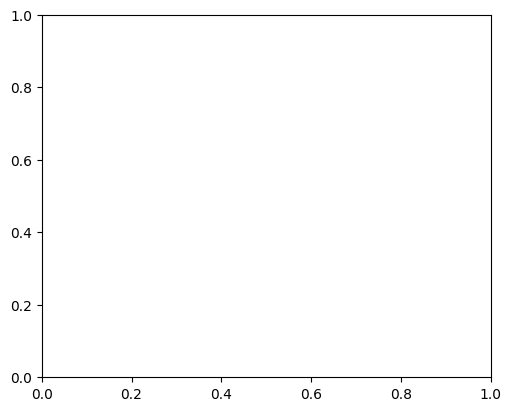

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt



# --- UI ---
metric_dropdown = widgets.Dropdown(
    options=["Recall (Collider)", "F1 (Collider)", "SHD [CPDAG]", "Recall (Synergy)", "Precision (Collider)", "Recall (Pairwise)"],
    value="Recall (Collider)",
    description="Metric:",
)

out = widgets.Output()

def render(metric: str):
    """Render the heatmap for the selected metric."""
    with out:
        clear_output(wait=True)

        # Important: close prior figures to avoid stacking / memory leaks
        plt.close("all")

        fig, axes = plot_final_heatmap(
            results_by_label,
            subset_metrics=[metric, x_col, y_col, filter_col],
            plot_metric=metric,
            x_col=x_col,
            aggfunc="min",
            y_col=y_col,
            filter=(filter_col, filter_val),
        )

        # Ensure the latest figure is shown in the output area
        plt.show()

def on_metric_change(change):
    if change["name"] == "value":
        render(change["new"])

metric_dropdown.observe(on_metric_change, names="value")

# Display UI + initial render
display(widgets.VBox([metric_dropdown, out]))
render(metric_dropdown.value)


## 1.3: Varying MI/WMS-Synergy (JointPMF)

In [58]:
import pickle

subset = 'jpmf_grid'
# subset = 'toyMedium'

# mapping="experiments/RQ1/jpmf_grid/grid_mapping.csv"

x_col="target_mi"
y_col="syn_cutoff"
filter_col, filter_val = ("pair_probs", 0.5)
load_results(subset)

display(widgets.VBox([metric_dropdown, out]))
render(metric_dropdown.value)

In [45]:
### Metrics and Algorithms